# Shamir Maharjan
# 2417731

# MCP NEURONS AND PRECPTRONS

Feature 	MCP Neuron (1943)	         Perceptron (1957)

Learning	None. Weights are fixed/pre-programmed.	   Automatic. Weights update via the Learning Rule.

Input Type	Only Binary (0 or 1).	    Real numbers (e.g., 0.5, -2.1, 100).

Weights	All inputs usually have equal weight.	    Each input has its own unique weight.

Use Case	Hard-coding simple Logic Gates (AND, OR, NOT).	    Linear Classification of complex data.

# 3.1 Mathematical Formalization of the MCP Neuron:

Algorithm 1 MCP Neuron Model

1: Input: x1, x2, . . . , xn (n inputs)

2: Output: y (output of the neuron)

3: Step 1: Compute the sum of inputs:

g(X) = Xn
i=1
xi

4: Step 2: If any input xi is inhibitory, set the output to 0:

5: if any input xi is inhibitory then

6: y ← 0

7: else

8: Step 3: If g(X) ≥ T, then set the output to 1, else 0:

9: if g(X) ≥ T then

10: y ← 1

11: else

12: y ← 0

13: end if

14: end if

# 3.2 Task - 1: Implementation of MCP Neurons:

1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two inputs:
    
Hint:
    
• Aggregate all the inputs.
    
• Handcraft a Threshold values for ”AND” and ”OR” Function.
    
• Implement a if else statement as stated above.

## For AND Operator

In [28]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1 nd array): An array of binary values.
    X2 (1 nd array): An array of binary values.
    Output:
    state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
    """
    assert len(X1) == len(X2)
    
    state_neuron = []
    for i in range(len(X1)):
        weighted_sum = X1[i] + X2[i]

        if weighted_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
        

    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let’s name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    return state_neuron


## Sample Usage for ”AND” Function.

In [29]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


## For OR Operations.

In [30]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        weighted_sum = X1[i] + X2[i]

        if weighted_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let’s name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    return state_neuron

## Sample Usage for ”OR” Function.

In [31]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


## 3.2.1 Answer the Following Question:

### • Question - 1: List out all the limitations of MCP - Neurons.

The limitations of MCP - Neurons are:

1. The inputs can only be 0 and 1.
   
2. There is a fixed weight, so user have to set weight manually.

3. The is no Learning Rule so if the output is wrong, it wont try to make it correct by changing the weights.

4. Cant solve non linear seperable problem (XOR)

5. The output is strictly binary. It cannot output probabilities (e.g., 80% sure this is a 1).



### • Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

No, I cannot devise a single set of weights () and a threshold () for one MCP neuron to solve XOR.

An MCP neuron makes a decision based on a linear boundary. The 1s are on opposite corners (0,1 and 1,0), and the 0s are on the other corners (0,0 and 1,1). No single straight line can separate them.

# 4 The Perceptron.

## Task 2: Perceptron Algorithm for 0 vs 1 Classification.

### Load the Dataset:

In [32]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 3\\mnist_0_and_1.csv") 
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### 1. Question - 1: What does the shape of X represent?

Shape of X represent the feature matrix, which contains the features, to the output label, it has 12665 rows (samples or images) and 784 columns (pixels per image). 

### Question - 2: What does the shape of Y represent?

shape of Y represents label vectors meaning, Each row in y corresponds to the label of that image.  shape: (12665,) = Labels for each of the 12,665 images (either 0 or 1)

### Visualize the Dataset:

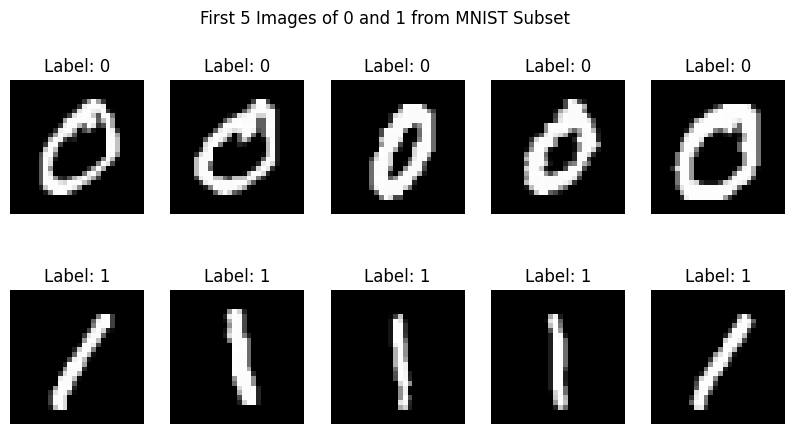

In [33]:
import matplotlib.pyplot as plt
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
    # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
    # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

### 3. Initialize Weights and Bias:

In [34]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

### Question - 3: What does the weights array represent in this context?

The weight array represents the there are 784 weight one for each feature in traning dataset. Each weight represents how much influence that particular pixel has on the final prediction

## Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Zero initialization is used here for simplicity and because it works for a single perceptron. There is no bias toward any feature initially. Results are reproducible (no randomness)

## 4. Implement a Decision Function or Activation Function:

In [35]:
import numpy as np
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############ # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0);  # np.where(condition, value_if_true, value_if_false)
    return y_pred_all

## 5. Implement the Perceptron Learning Algorithm:

In [40]:
import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)
    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        correct_count = 0
        y_pred_all = decision_function(X, weights, bias)

        for i in range(X.shape[0]):
            X_sample = X[i]
            y_pred_single = y_pred_all[i]
            y_true = y[i]

            error = y_true - y_pred_single

            if error !=0:
                weights = weights + learning_rate * error * X_sample
                bias = bias + learning_rate * error
            else:
                correct_count +=1

        if (epoch + 1) % 10 ==0:
            epoch_accuracy = (correct_count/ X.shape[0]) * 100
            print(f"Epoch {epoch+1}, Accuracy: {epoch_accuracy:.2f}%")

    y_pred_final = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred_final == y) / len(y) * 100

    return weights, bias, accuracy

## Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Here we are using Linear Activation Function, ax+b. This function computes the raw decision score for a sample.

## Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction is wrong, the model adjusts weights and bias to fix future predictions. If error is positive we add to weights (move in positive direction)

If error is negative we subtract from weights (move in negative direction)

Bias gets the same adjustment (but no multiplier)

##  Question - 7:Why is the final accuracy important, and what do you expect it to be?

Final accuracy tells us how well our trained model performs. It measures the percentage of correct predictions. 

For linearly separable data:

Expected accuracy: 100% or very close (95-99%)

The perceptron will find a perfect decision boundary if one exists

For non-linearly separable data (data that can't be separated by a straight line):

Expected accuracy: 50-80% depending on how messy the data is

The perceptron will get stuck and won't improve beyond a certain point

In [41]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10, Accuracy: 99.34%
Epoch 20, Accuracy: 99.54%
Epoch 30, Accuracy: 99.63%
Epoch 40, Accuracy: 99.66%
Epoch 50, Accuracy: 99.68%
Epoch 60, Accuracy: 99.70%
Epoch 70, Accuracy: 99.72%
Epoch 80, Accuracy: 99.72%
Epoch 90, Accuracy: 99.72%
Epoch 100, Accuracy: 99.74%
The Final Accuracy is:  99.73943939992104


## 7. Visualizing the Misclassified Image:

Final Accuracy: 0.9974


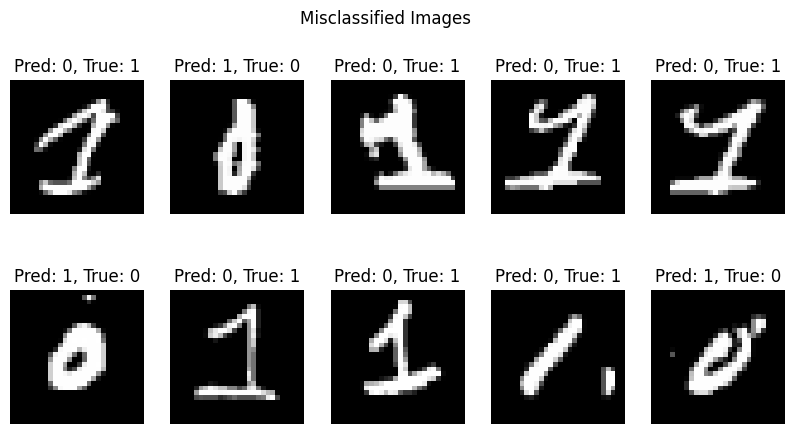

In [42]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

## Question - 8:What does misclassified idx store, and how is it used in this code?

Misclassified_idx stores the indices (positions) of all images that were predicted incorrectly.
    
y_pred != y = creates a boolean array (True where predictions don't match true labels)

np.where(...) = finds positions where the condition is True

[0] = extracts just the indices (removes extra dimension)

Get all misclassified image positions: misclassified_idx = [5, 12, 27, ...]

Loop through first 10 misclassified images: for ax, idx in zip(axes.flat, misclassified_idx[:10])
For each misclassified index idx:

Display the image: X[idx]

Show what model predicted: y_pred[idx]

Show what it should be: y[idx]


## Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?

This message means your perceptron achieved 100% accuracy — it made zero mistakes on all the training data. 

We got Final Accuracy: 0.9974 = 99.74%
Almost perfect, but the code still shows 10 misclassified images
The model is very good, but not flawless on the training set